# 01 — Exploratory Data Analysis

**Purpose:** Understand the Credit Card Transactions Fraud Detection dataset
before any modeling decisions are made.

**Sections:**
1. Load & combine both CSV files
2. Structural inspection (shape, dtypes, head)
3. Missing values
4. Duplicates
5. Suspicious / invalid values
6. Target distribution (class imbalance)
7. Deeper EDA (distributions, fraud vs legitimate, correlations)

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

DATA_DIR = Path("..") / "data" / "raw"

train = pd.read_csv(DATA_DIR / "fraudTrain.csv")
test  = pd.read_csv(DATA_DIR / "fraudTest.csv")

print("fraudTrain.csv:", train.shape)
print("fraudTest.csv :", test.shape)

# Combine — it will be done on a stratified split later

df = pd.concat([train, test], ignore_index=True)
print("Combined      :", df.shape)

# Free memory — the original frames are no longer needed
del train, test

fraudTrain.csv: (1296675, 23)
fraudTest.csv : (555719, 23)
Combined      : (1852394, 23)


In [3]:
print("Shape:", df.shape)
print()
df.info()

Shape: (1852394, 23)

<class 'pandas.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  str    
 2   cc_num                 int64  
 3   merchant               str    
 4   category               str    
 5   amt                    float64
 6   first                  str    
 7   last                   str    
 8   gender                 str    
 9   street                 str    
 10  city                   str    
 11  state                  str    
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    str    
 17  dob                    str    
 18  trans_num              str    
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_frau

In [4]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
df.dtypes.to_frame("dtype")

,dtype
Unnamed: 0,int64
trans_date_trans_time,str
cc_num,int64
merchant,str
category,str
amt,float64
first,str
last,str
gender,str
street,str


In [6]:
missing = df.isnull().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(4)
missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)
print(f"Columns with missing values: {len(missing)}")
missing

Columns with missing values: 0


,missing_count,missing_pct


In [7]:
full_dupes = df.duplicated().sum()
print("Fully duplicated rows:", full_dupes)

if "trans_num" in df.columns:
    id_dupes = df["trans_num"].duplicated().sum()
    print("Duplicated trans_num:", id_dupes)

Fully duplicated rows: 0
Duplicated trans_num: 0


In [8]:
target_col = "is_fraud"

counts = df[target_col].value_counts().sort_index()
pcts   = (df[target_col].value_counts(normalize=True).sort_index() * 100).round(4)

summary = pd.DataFrame({"count": counts, "percent": pcts})
summary.index = ["Legitimate (0)", "Fraud (1)"]
print(summary)

legit = (df[target_col] == 0).sum()
fraud = (df[target_col] == 1).sum()
print(f"\nLegitimate : Fraud ≈ {legit/fraud:.1f} : 1")

                  count  percent
Legitimate (0)  1842743   99.479
Fraud (1)          9651    0.521

Legitimate : Fraud ≈ 190.9 : 1


In [9]:
# Numeric columns — min / max / mean to spot any impossible values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1852394.0,5.371934e+05,3.669110e+05,0.000000e+00,2.315490e+05,4.630980e+05,8.335758e+05,1.296674e+06
cc_num,1852394.0,4.173860e+17,1.309115e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1852394.0,7.006357e+01,1.592540e+02,1.000000e+00,9.640000e+00,4.745000e+01,8.310000e+01,2.894890e+04
zip,1852394.0,4.881326e+04,2.688185e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.992100e+04
lat,1852394.0,3.853931e+01,5.071470e+00,2.002710e+01,3.466890e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1852394.0,-9.022783e+01,1.374789e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1852394.0,8.864367e+04,3.014876e+05,2.300000e+01,7.410000e+02,2.443000e+03,2.032800e+04,2.906700e+06
unix_time,1852394.0,1.358674e+09,1.819508e+07,1.325376e+09,1.343017e+09,1.357089e+09,1.374581e+09,1.388534e+09
merch_lat,1852394.0,3.853898e+01,5.105604e+00,1.902742e+01,3.474012e+01,3.936890e+01,4.195626e+01,6.751027e+01
merch_long,1852394.0,-9.022794e+01,1.375969e+01,-1.666716e+02,-9.689944e+01,-8.744069e+01,-8.024511e+01,-6.695090e+01


In [10]:
# Categorical columns — how many unique values each of them holds
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols:
    print(f"{c:25s} unique={df[c].nunique():>8,}  sample={df[c].dropna().unique()[:3]}")

C:\Users\T480S\AppData\Local\Temp\ipykernel_18696\572298659.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


trans_date_trans_time     unique=1,819,551  sample=<StringArray>
['2019-01-01 00:00:18', '2019-01-01 00:00:44', '2019-01-01 00:00:51']
Length: 3, dtype: str
merchant                  unique=     693  sample=<StringArray>
['fraud_Rippin, Kub and Mann', 'fraud_Heller, Gutmann and Zieme', 'fraud_Lind-Buckridge']
Length: 3, dtype: str
category                  unique=      14  sample=<StringArray>
['misc_net', 'grocery_pos', 'entertainment']
Length: 3, dtype: str
first                     unique=     355  sample=<StringArray>
['Jennifer', 'Stephanie', 'Edward']
Length: 3, dtype: str
last                      unique=     486  sample=<StringArray>
['Banks', 'Gill', 'Sanchez']
Length: 3, dtype: str
gender                    unique=       2  sample=<StringArray>
['F', 'M']
Length: 2, dtype: str
street                    unique=     999  sample=<StringArray>
['561 Perry Cove', '43039 Riley Greens Suite 393', '594 White Dale Suite 530']
Length: 3, dtype: str
city                      unique=    

## Observations from Initial Inspection

Alright, first pass done. Here's what the data looks like after loading and combining both CSVs.

### Size & Shape
- Combined dataset: **1,852,394 rows × 23 columns** (1.29M from fraudTrain + 555K from fraudTest).
- In-memory footprint: **~325 MB**.
- Every transaction has a unique `trans_num`, and there are zero full-row duplicates. So the dataset is clean on the duplication front.

### Missing Data
- **Zero missing values** in any column. Nothing to impute.
- Caveat: no NaNs doesn't automatically mean "complete." A value could be encoded as an empty string or a placeholder like -1 and still show up as "present." I checked the numeric ranges and nothing jumped out as a disguised null, but keeping an eye on this.

### The Big One — Class Imbalance
- **1,842,743 legitimate** (99.479%)
- **9,651 fraudulent** (0.521%)
- Ratio: **~191 : 1**

This is the defining feature of the dataset. A model that just predicts "not fraud" for everything would score **99.48% accuracy** while catching **zero fraud**. So accuracy is basically useless as a headline metric here. The metrics that matter for this project will be
**Precision, Recall, F1, and Average Precision (AP)**.

### Column Types
- 5 × float64 (`amt`, `lat`, `long`, `merch_lat`, `merch_long`)
- 6 × int64 (including `is_fraud`, our target)
- 12 × str (text columns)

Two columns need conversion before modeling:
- `trans_date_trans_time` — currently a string, should be datetime.
- `dob` — same story, and it's also PII.

### Column-Level Notes

**Junk column to drop:**
- `Unnamed: 0` — this is the row index from the original CSVs that got
  written into the file when they were saved. Its max value is only
  1,296,674 while we have 1,852,394 rows, which confirms it's not even a
  valid counter anymore after combining the two files. Drop it.

**PII to drop (no reason for a fraud model to see names/addresses):**
- `cc_num`, `first`, `last`, `street`, `city`, `zip`, `dob`, `trans_num`.

**Categorical columns — cardinality matters for encoding later:**
- Easy one-hot: `gender` (2 values), `category` (14 values).
- Medium cardinality, decision needed: `state` (51), `merchant` (693),`city` (906), `street` (999). One-hot would blow up the feature space for these.
- Never one-hot: `trans_date_trans_time` — 1.8M unique values.

**Numeric ranges — all sane:**
- `amt`: $1.00 to $28,948.90 — no negatives, no zeros, no absurd maxes.
- `lat` / `long` / `merch_lat` / `merch_long`: all within US bounds.
- `city_pop`: 23 to 2.9M — small towns to NYC.
- `unix_time`: ~2019 to ~2020.

### Things That Looked Suspicious But Aren't
- Every merchant name starts with `fraud_` — e.g. `fraud_Rippin, Kub and Mann`. This looked like a leak at first glance, but it's a naming convention in the synthetic data. Verified: it appears on merchants serving both fraud and non-fraud transactions, so it's not a leak.

### Misc
- Pandas 3.0 threw a deprecation warning when I filtered text columns with `include=["object"]`. It still works for now, but pandas 4.0 will require `include=["str", "string"]`. Just noting it here so future-me isn't confused when it becomes an error.
- The combined DataFrame's index is unique (thanks to `ignore_index=True` on concat), so `Unnamed: 0` is the only column with non-unique values is another reason it's useless.

### Next Up
Now that the data is inspected, the next notebook step is deeper EDA — distributions, fraud vs legitimate comparisons, correlations, and a first look at feature relationships. Then preprocessing.

In [11]:
import subprocess
for f in ["data/raw/fraudTrain.csv", "data/raw/fraudTest.csv"]:
    r = subprocess.run(["git", "check-ignore", "-v", f], capture_output=True, text=True)
    print(f"{f} → {r.stdout.strip() or 'NOT IGNORED ⚠️'}")

data/raw/fraudTrain.csv → .gitignore:4:*.csv	data/raw/fraudTrain.csv
data/raw/fraudTest.csv → .gitignore:4:*.csv	data/raw/fraudTest.csv


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12

FRAUD_COLORS = {0: "#4C72B0", 1: "#C44E52"}  # blue = legit, red = fraud
FRAUD_LABELS = {0: "Legitimate", 1: "Fraud"}

# Sampled frame for plots that can't handle the 1.85M rows.
df_sample = df.sample(n=100_000, random_state=42)
print("Sample shape:", df_sample.shape)
print("Sample fraud rate:", round(df_sample["is_fraud"].mean() * 100, 3), "%")

Sample shape: (100000, 23)
Sample fraud rate: 0.543 %


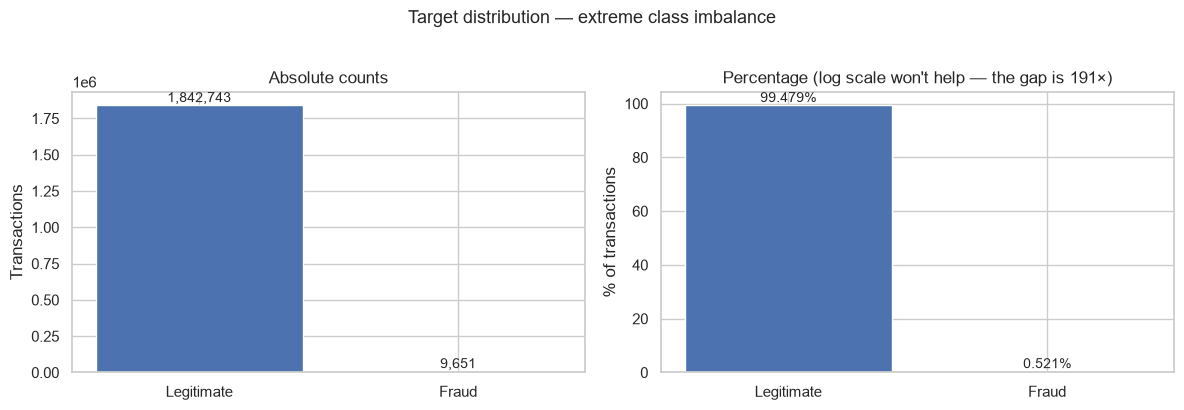

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["is_fraud"].value_counts().sort_index()
axes[0].bar(["Legitimate", "Fraud"], counts.values, color=[FRAUD_COLORS[0], FRAUD_COLORS[1]])
axes[0].set_title("Absolute counts")
axes[0].set_ylabel("Transactions")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

pcts = df["is_fraud"].value_counts(normalize=True).sort_index() * 100
axes[1].bar(["Legitimate", "Fraud"], pcts.values, color=[FRAUD_COLORS[0], FRAUD_COLORS[1]])
axes[1].set_title("Percentage (log scale won't help — the gap is 191×)")
axes[1].set_ylabel("% of transactions")
for i, v in enumerate(pcts.values):
    axes[1].text(i, v, f"{v:.3f}%", ha="center", va="bottom", fontsize=10)

plt.suptitle("Target distribution — extreme class imbalance", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

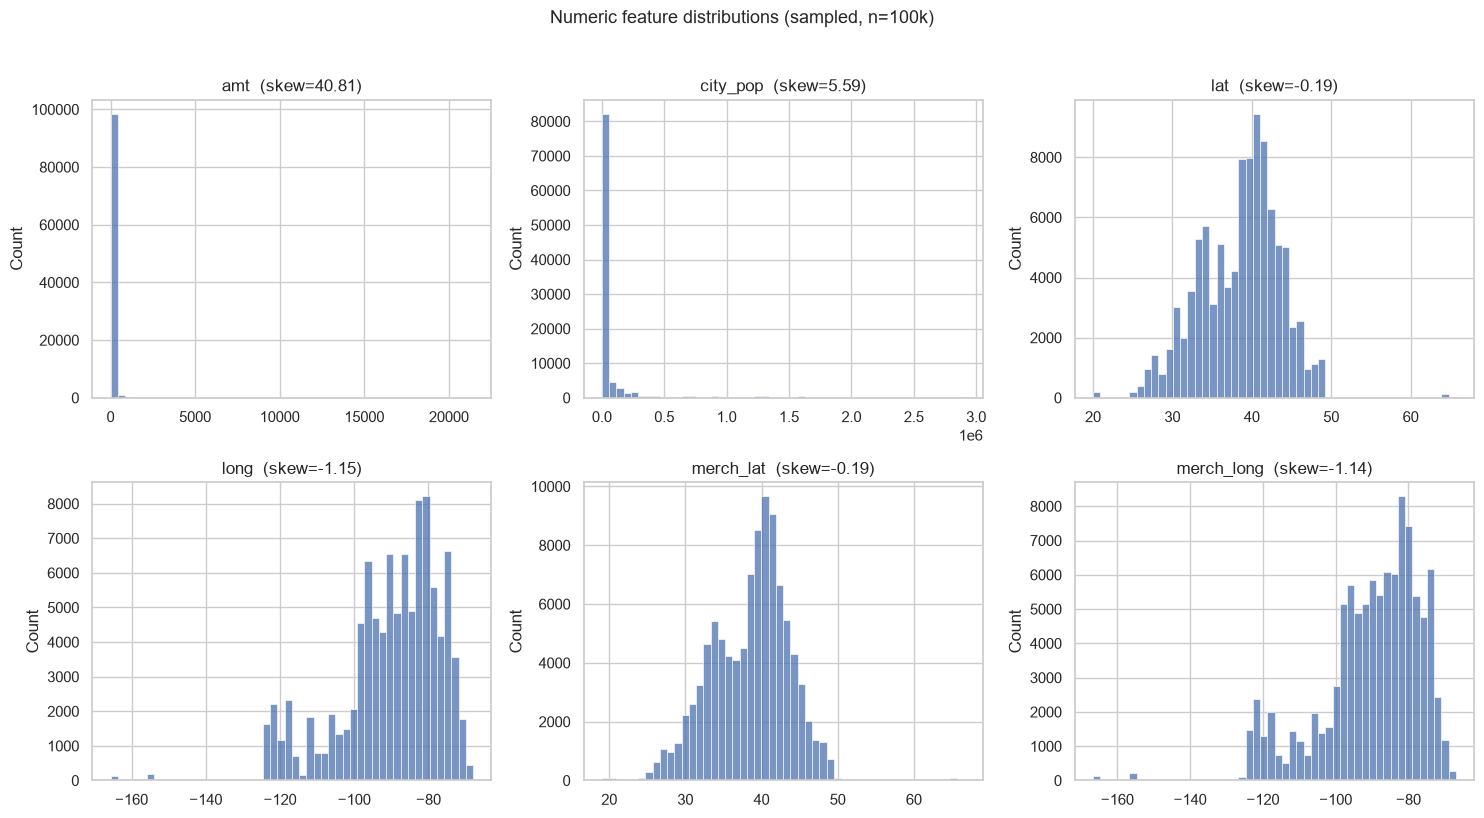

In [14]:
numeric_cols = ["amt", "city_pop", "lat", "long", "merch_lat", "merch_long"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_sample[col], bins=50, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col}  (skew={df[col].skew():.2f})")
    axes[i].set_xlabel("")

plt.suptitle("Numeric feature distributions (sampled, n=100k)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

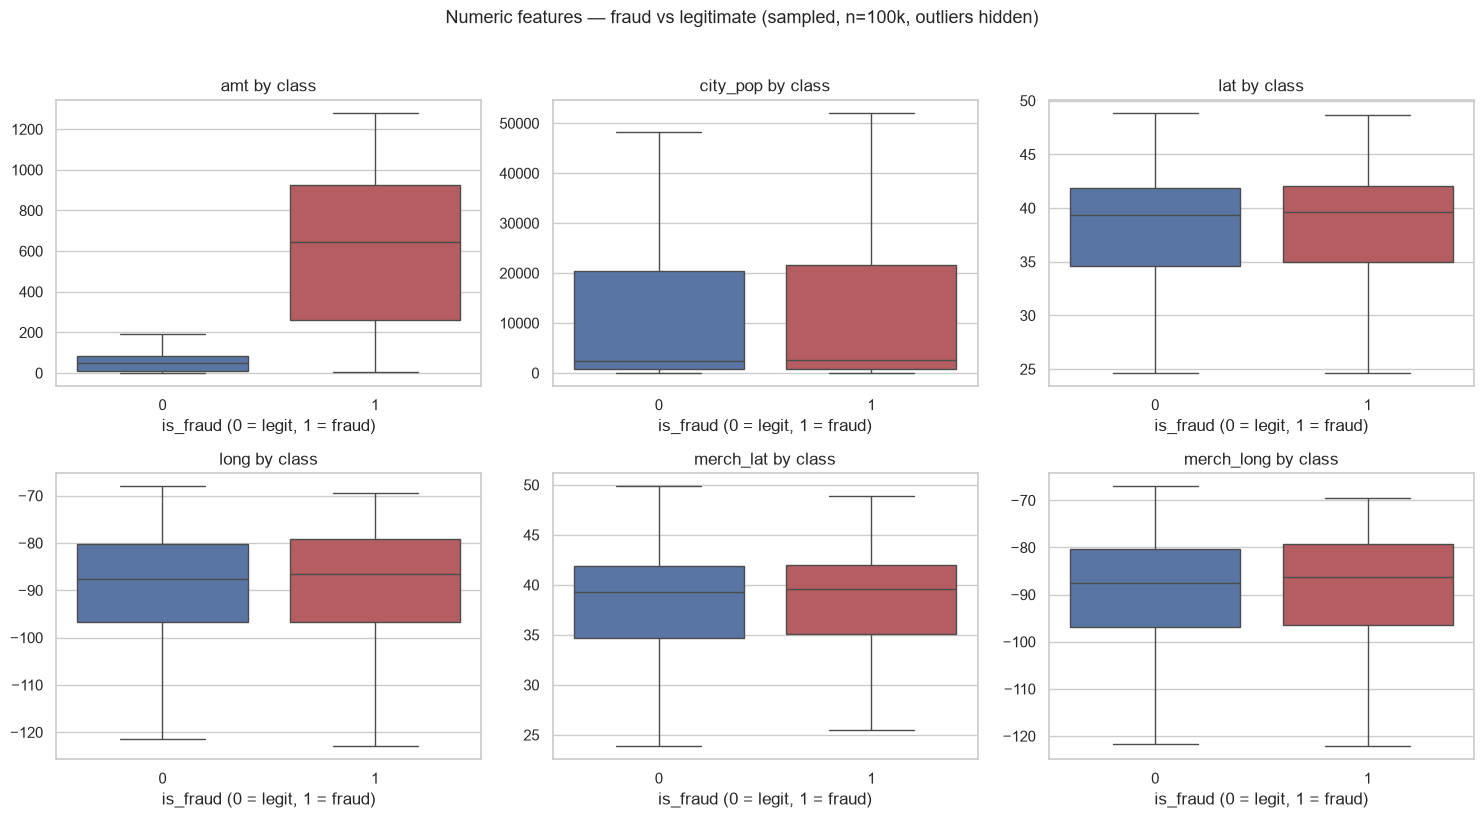

amt          city_pop            lat          long        merch_lat        merch_long       
              mean  median      mean  median   mean median   mean median      mean median       mean median
Legitimate   67.36   47.07  90270.08  2456.0  38.52  39.34 -90.25 -87.59     38.51  39.33     -90.25 -87.49
Fraud       555.20  645.21  98424.46  2566.0  38.79  39.61 -89.44 -86.55     38.77  39.63     -89.44 -86.23

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df_sample, x="is_fraud", y=col, ax=axes[i],
        hue="is_fraud",
        palette={0: "#4C72B0", 1: "#C44E52"},
        legend=False,
        showfliers=False,
    )
    axes[i].set_title(f"{col} by class")
    axes[i].set_xlabel("is_fraud (0 = legit, 1 = fraud)")
    axes[i].set_ylabel("")

plt.suptitle("Numeric features — fraud vs legitimate (sampled, n=100k, outliers hidden)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Class-conditional stats for the same features
stats = df_sample.groupby("is_fraud")[numeric_cols].agg(["mean", "median"]).round(2)
stats.index = ["Legitimate", "Fraud"]
stats

### Numeric features — fraud vs legitimate (boxplots + stats)

Alright, so out of all six numeric features I plotted, only one of them actually does anything: **`amt`**.

The fraud box is sitting way up the y-axis compared to legit. Median around **645 vs 47**, mean roughly 8× bigger. That's not a subtle shift — that's a real gap, and it lines up with what the earlier histogram already hinted at. Transaction amount is the strongest raw numeric signal I have.

The rest? Basically flat.

- `city_pop` — 90,270 vs 98,424 on the mean, 2,456 vs 2,566 on the median. Almost identical. Dead weight as-is.
- `lat` / `long` — fraud sits a *tiny* bit higher and a *tiny* bit east on average. Statistically real at 1.8M rows, but the boxes overlap almost completely. Can't use these coordinates raw.
- `merch_lat` / `merch_long` — same story. Small consistent shift, huge overlap.

One thing worth noting: the geographic shift is *consistent* across all four coordinates — fraud is always slightly up-and-right of legit. That's not a coincidence. It hints that the **distance between cardholder and merchant** might actually differ between classes, which is a feature I can engineer during preprocessing. Raw lat/long are useless, but the *derived* distance is worth testing.

**So, going forward:**

- `amt` — the one raw numeric feature I trust. Worth a `log1p` transform so linear models can use it properly.
- `lat`/`long`/`merch_lat`/`merch_long` — drop the raw versions, engineer distance instead.
- `city_pop` — keep it if it's cheap, but I'm not expecting it to contribute.

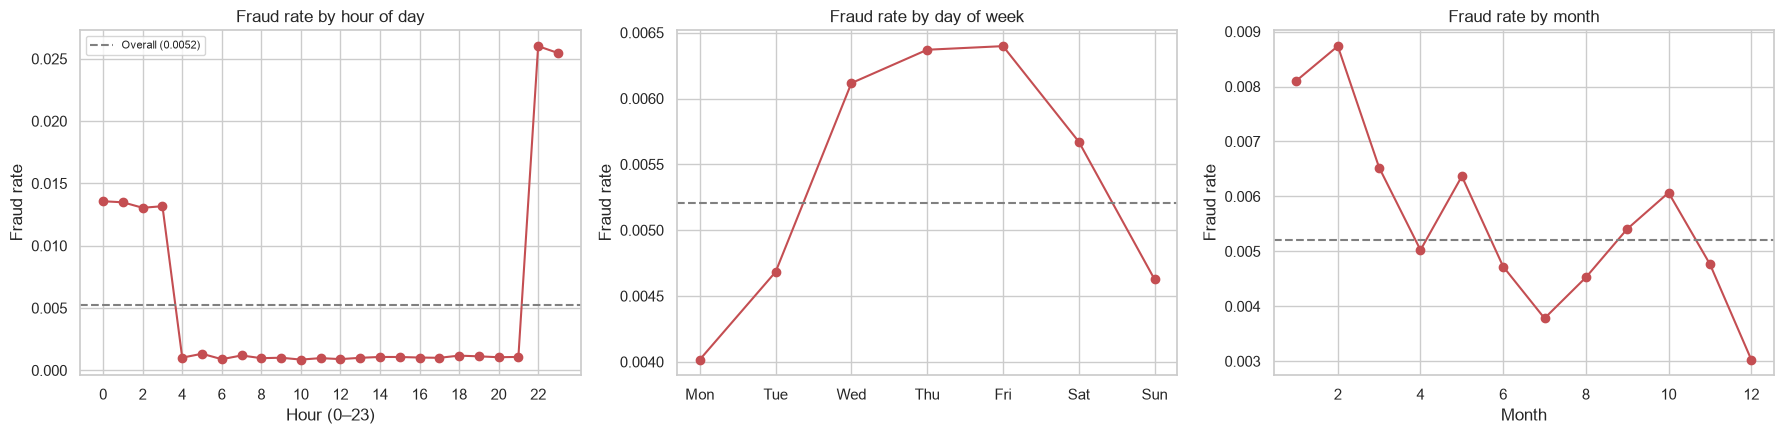

In [20]:
# Convert timestamp to datetime, then extract temporal features for EDA
# (feature engineering proper happens after the split)
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

df["hour"] = df["trans_date_trans_time"].dt.hour
df["day_of_week"] = df["trans_date_trans_time"].dt.dayofweek   # 0=Mon, 6=Sun
df["month"] = df["trans_date_trans_time"].dt.month

overall_rate = df["is_fraud"].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Hour of day
hourly = df.groupby("hour")["is_fraud"].mean()
axes[0].plot(hourly.index, hourly.values, marker="o", color="#C44E52")
axes[0].axhline(overall_rate, ls="--", color="gray",
                label=f"Overall ({overall_rate:.4f})")
axes[0].set_title("Fraud rate by hour of day")
axes[0].set_xlabel("Hour (0–23)")
axes[0].set_ylabel("Fraud rate")
axes[0].set_xticks(range(0, 24, 2))
axes[0].legend(fontsize=8)

# Day of week
dow = df.groupby("day_of_week")["is_fraud"].mean()
axes[1].plot(dow.index, dow.values, marker="o", color="#C44E52")
axes[1].axhline(overall_rate, ls="--", color="gray")
axes[1].set_title("Fraud rate by day of week")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_ylabel("Fraud rate")

# Month
monthly = df.groupby("month")["is_fraud"].mean()
axes[2].plot(monthly.index, monthly.values, marker="o", color="#C44E52")
axes[2].axhline(overall_rate, ls="--", color="gray")
axes[2].set_title("Fraud rate by month")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Fraud rate")

plt.tight_layout()
plt.show()


### 8.x Temporal features — observation

Alright, this one surprised me a bit.

**Hour of day** is by far the loudest of the three. Look at the shape — it's sitting around 0.013–0.014 from midnight to 3am, then at hour 4 it just drops off a cliff and stays basically flat at zero all the way through hour 21. Then at 22 and 23 it rockets back up to 0.025 and 0.026.

The thing that clicked after staring at it for a sec: hours 0–3 and hours 22–23 are the *same window*. The axis just cuts it at midnight. So really, fraud clusters hard into a nighttime band from roughly 22:00 to 03:00, and is almost nonexistent during normal waking hours. That's more than 4× the overall rate at the peak. Matches the real-world intuition too — fraudsters work when cardholders are asleep and monitoring teams are thin.

**Day of week** is mild. Peaks around Wed–Fri (0.0063–0.0065), bottoms out Monday (0.0040). That's roughly a 1.6× spread, so it's a real signal but nowhere near as strong as hour. Cheap to keep, won't carry the model.

**Month** is noisy. Peaks at month 2 (0.0087), drops to month 12 (0.0030), wiggles in between with no obvious pattern. Given the dataset is synthetic, I'm fairly sure this is just sampling noise. I'll still create the feature since it costs nothing, but I'm not expecting it to matter.

**The interesting bit for later:** `hour` isn't linear. It's not "more hours = more fraud" — it's a specific window. That kind of shape is exactly what tree-based models eat for breakfast and what linear models choke on. One more nudge toward Random Forest being a natural fit.

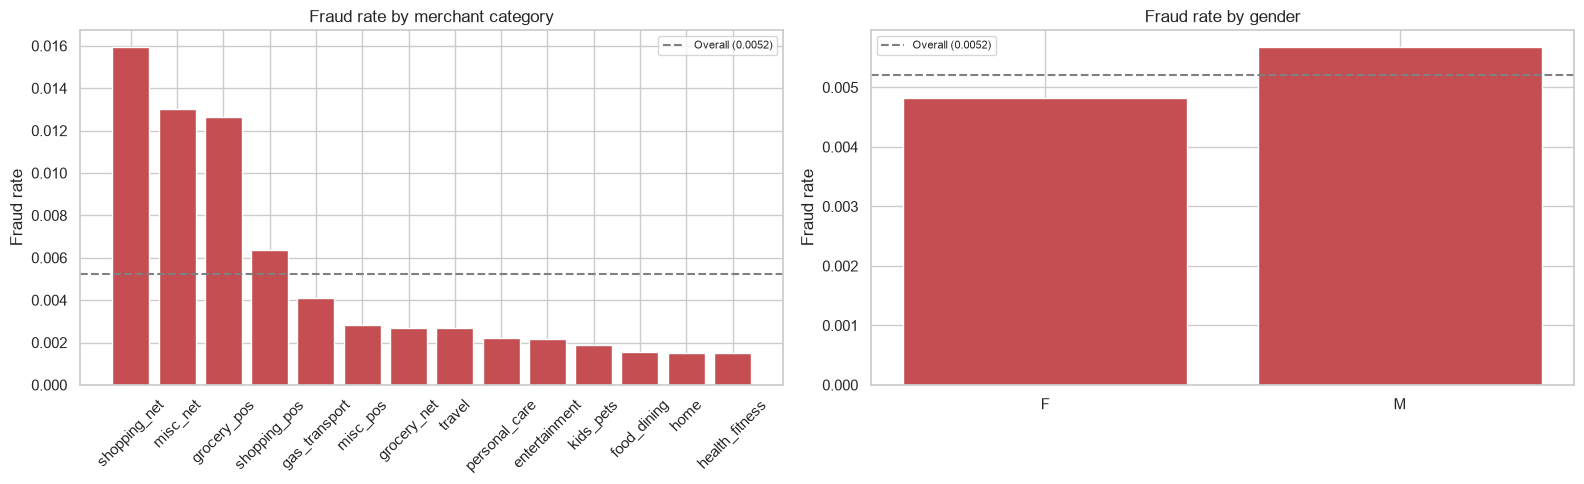

Fraud rate by category (sorted):
                   mean   count
category                       
shopping_net    0.01593  139322
misc_net        0.01304   90654
grocery_pos     0.01265  176191
shopping_pos    0.00634  166463
gas_transport   0.00411  188029
misc_pos        0.00282  114229
grocery_net     0.00270   64878
travel          0.00269   57956
personal_care   0.00223  130085
entertainment   0.00218  134118
kids_pets       0.00188  161727
food_dining     0.00157  130729
home            0.00151  175460
health_fitness  0.00151  122553

Fraud rate by gender:
           mean    count
gender                  
F       0.00483  1014749
M       0.00567   837645

Top 10 states by fraud rate (min 5,000 transactions):
          mean   count
state                 
OR     0.00746   26408
NH     0.00674   11727
VA     0.00654   41756
TN     0.00638   24913
NE     0.00627   34425
MN     0.00616   45433
NY     0.00611  119419
DC     0.00604    5130
KS     0.00586   32939
NV     0.00583    8058



In [22]:
# Categorical features — fraud rate by group
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- category ---
cat_stats = (df.groupby("category")["is_fraud"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False))

axes[0].bar(cat_stats.index, cat_stats["mean"], color="#C44E52")
axes[0].axhline(overall_rate, ls="--", color="gray",
                label=f"Overall ({overall_rate:.4f})")
axes[0].set_title("Fraud rate by merchant category")
axes[0].set_ylabel("Fraud rate")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(fontsize=8)

# --- gender ---
gender_stats = df.groupby("gender")["is_fraud"].agg(["mean", "count"])
axes[1].bar(gender_stats.index, gender_stats["mean"], color="#C44E52")
axes[1].axhline(overall_rate, ls="--", color="gray",
                label=f"Overall ({overall_rate:.4f})")
axes[1].set_title("Fraud rate by gender")
axes[1].set_ylabel("Fraud rate")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Fraud rate by category (sorted):")
print(cat_stats.round(5).to_string())

print("\nFraud rate by gender:")
print(gender_stats.round(5).to_string())

# --- state: top and bottom by fraud rate, filtered to states with enough volume ---
state_stats = (df.groupby("state")["is_fraud"]
                .agg(["mean", "count"])
                .query("count >= 5000")
                .sort_values("mean", ascending=False))

print("\nTop 10 states by fraud rate (min 5,000 transactions):")
print(state_stats.head(10).round(5).to_string())

print("\nBottom 5 states by fraud rate:")
print(state_stats.tail(5).round(5).to_string())

### State — observation

Okay, so `state` is a real signal but it's much weaker than `category`. Way weaker.

Top is **OR at 0.00746** (~1.4× overall), bottom is **LA at 0.00377** (~0.7× overall). So the full spread top-to-bottom is roughly **2×**. Compare that to `category`'s 10× spread and it's not even close.

There's also no obvious geographic story I can latch onto. OR, NH, VA, TN at the top — nothing that screams "coastal fraud hub" or "rural lower risk". NY shows up in the top 10 with 119k transactions which is the only one that intuitively makes sense (more people, more fraud). But that's a population effect, not a state effect, and `city_pop` is already a feature.

The other thing nagging at me: `state` is correlated with `lat`/`long`, `city`, and `zip` — all of which are being dropped as PII or engineered into distance. So `state` might end up being partially redundant with whatever geographic signal survives. Worth keeping for now since the encoding cost is low (51 categories → one-hot is fine), but I'm flagging it as "probably a weak contributor" rather than "load-bearing feature".

So the categorical picture is:
- **`category`** — first-class feature, 10× spread, clear pattern
- **`state`** — mild signal, ~2× spread, no clean story
- **`gender`** — flat, near-useless

That lines up with what I'd expect for a synthetic fraud dataset — the generator clearly built fraud propensity into `category` and `hour` most strongly, and the rest is more or less noise.

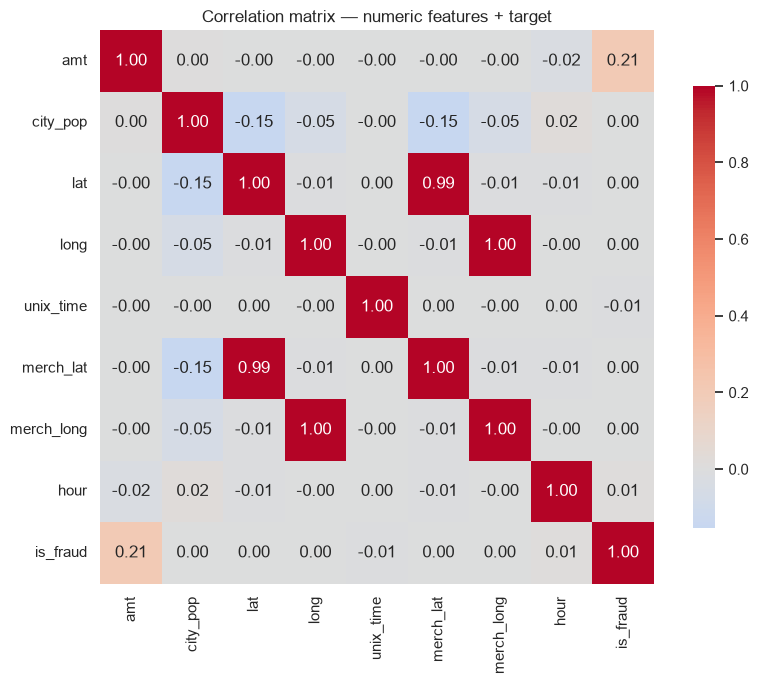

Correlation of each numeric feature with is_fraud (|sorted|):
amt           0.2093
unix_time    -0.0133
hour          0.0132
lat           0.0029
merch_lat     0.0028
long          0.0010
merch_long    0.0010
city_pop      0.0003


In [24]:
# Correlation matrix — numeric features + target
corr_cols = ["amt", "city_pop", "lat", "long", "unix_time",
            "merch_lat", "merch_long", "hour", "is_fraud"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix — numeric features + target")
plt.tight_layout()
plt.show()

# Feature correlation with target, ranked by absolute value
target_corr = (corr["is_fraud"]
            .drop("is_fraud")
            .sort_values(key=lambda s: s.abs(), ascending=False))
print("Correlation of each numeric feature with is_fraud (|sorted|):")
print(target_corr.round(4).to_string())

### Correlations — observation

Two things jump out here, and one of them is a problem I need to flag.

**Thing 1 — the "distance" idea is dead.**

Look at the top of the matrix: `lat ↔ merch_lat = 0.99`, and `long ↔ merch_long = 1.00`. The cardholder coordinates and merchant coordinates are *basically the same variable*. That's because the synthetic data generator seems to have created merchant locations as tiny perturbations of cardholder locations. So the "distance between cardholder and merchant" feature I was hoping to engineer earlier is going to be near-zero for almost every transaction. That kills that plan. Good catch before I wasted time building it.

**Thing 2 — `amt` is the only feature that correlates with target.**

The ranked table says it all: `amt = 0.2093`, then everything else is basically noise — `unix_time = -0.0133`, `hour = 0.0132`, then down to `city_pop = 0.0003`. So out of the raw numeric features, only `amt` actually moves with the target.

But here's the catch: **Pearson correlation only catches linear relationships.** And `hour` is *not* linear — I already saw that in the earlier plot, it's a U-shaped thing around midnight. The correlation number (0.013) makes it look useless, but the plot showed a 4× fraud rate spike overnight. So the takeaway isn't "hour is useless" — it's "hour's signal isn't linear, so linear models will miss it and tree models will catch it."

Same story for `category` — it's a string, so it's not even in this matrix, but the earlier bar chart showed a 10× spread. Pearson can't see it. That's fine — I already know it's strong.

**So the takeaways:**

- `amt` is the only raw numeric feature with a linear signal.
- Geographic features are basically duplicated (lat ≈ merch_lat, long ≈ merch_long), so the distance idea is out.
- `hour` and `category` are strong but *nonlinear* — which is one more vote for Random Forest over Logistic Regression.
- Correlation being small for most features is normal for fraud. Fraud isn't "one feature gives it away" — it's "the combination." Trees handle that naturally.